In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Coverage with accuracy

In [2]:
# load data extracted for a specific model


keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = "post_processed_test_reports_gaps_chunksize1000_llama-3.3-70b-versatile_v060426_v060426_geo"
# "post_processed_test_reports_gaps_chunksize1000_llama-3.3-70b-versatile_v060426_v060426_geo"
# "post_processed_labelled_reports_gaps_llama-3.3-70b-versatile_v270326_v270326_geo"  # merged_subtypes_

# load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_gaps_v050426_v050426_geo"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v271025"
suffix3 = suffix + "_v171025"
# load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+".gpkg"))
# load corresponding matched data
filename_match = f"matched_data_ws7qt-ws5ql-geo-valuepre-loose-nans_{res_savename_ext}"
# f"matched_data_ws2-geo-valuepre-strict-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    if "quanti" not in df.columns:
        df["quanti"] = df["impactValue"].notnull()
        df.loc[df["quanti"],"quanti"] = "quanti"
        df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

# compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

In [3]:
labelled_df.impactSubtype.value_counts()

impactSubtype
Affected People                                61
Residential Buildings                          42
Water, Sanitation, and Hygiene                 23
Agriculture and Access to Food                 21
Displaced People                               17
Transportation                                 15
Infected and Ill People                        15
Human Deaths                                   10
Economy and Livelihood                          9
Injured People                                  8
Informal Settlements                            8
Healthcare                                      8
Education                                       7
Homeless People                                 6
Human Health and Wellbeing                      5
Undefined Infrastructure and Service Access     4
Missing People                                  1
IT and Communication                            1
Name: count, dtype: int64

In [4]:
extracted_df.impactSubtype.value_counts()

impactSubtype
Affected People                           123
Residential Buildings                      75
Water, Sanitation, and Hygiene             67
Agriculture and Access to Food             56
Infected and Ill People                    38
Human Health and Wellbeing                 36
Displaced People                           35
Economy and Livelihood                     31
Healthcare                                 28
Transportation                             23
Human Deaths                               16
Targeted People                            14
Education                                  13
DREF Allocation & Funding requirements     12
Injured People                             10
Homeless People                            10
Assisted People                             5
Informal Settlements                        3
Missing People                              2
Power and Energy Production                 1
Name: count, dtype: int64

In [5]:
## add other variables useful for analysis
# report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

# report type
file_path = (
    DATA_IN_JSONS
    / "preproc_text_sel_gaps_all_ifrc_reports_info_unnested_with_text_v181125_v050326.csv"
)  #'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


# add vars to dfs
#extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
#labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
#matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])

In [6]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


In [7]:
from src.sanity_checks import flag_remove_cat
remove_cats = [
    "Unknown",
    "DREF Allocation & Funding requirements",
    "Targeted People",
    "Assisted People",
    "Other Human Impacts",
    "Other Infrastructural Impacts",
    "Other Agricultural Impacts",
    "Other Service Access Impacts",
]  # "Human Health and Wellbeing", "Economy and Livelihood"
extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

In [ ]:
#define threshold above which we consider a match

value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_remove_cat", "flag_unit_nonstd", "flag_percent", "flag_remove_unit"]#["flag_unit_nonstd"
keep_vars = []#["appealType", "reportSize", "reportDate"]
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)s
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
missed_df = labelled_df_filter[~labelled_df_filter.index.isin(matched_df_filter2["lab_match_id_sim"])]
false_positives_df = extracted_df_filter[~extracted_df_filter.index.isin(matched_df_filter2["ext_match_id_sim"])]
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=keep_vars).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

In [9]:
missed_df.appealCode.value_counts()

appealCode
MDRUG050    25
MDRSD034    24
MDRYE011    17
MDRRW022     5
Name: count, dtype: int64

In [37]:
missed_df.appealCode.value_counts()

appealCode
MDRSD034    48
MDRUG050    48
MDRYE011    26
MDRKE058    18
MDRS2001    17
MDRPK026    16
MDRBJ019    14
MDRDZ011    10
MDRCM039    10
MDRRW022     9
MDRNG041     9
MDRBD022     9
MDRIQ014     5
MDRMZ024     3
MDRSV012     3
MDRZM022     2
MDRMY003     1
MDRCN006     1
Name: count, dtype: int64

In [39]:
missed_df.impactSubtype.value_counts()

impactSubtype
Affected People                                65
Residential Buildings                          37
Agriculture and Access to Food                 24
Undefined Infrastructure and Service Access    19
Transportation                                 19
Infected and Ill People                        16
Economy and Livelihood                         14
Displaced People                               13
Water, Sanitation, and Hygiene                 11
Human Deaths                                    8
Human Health and Wellbeing                      4
Education                                       4
Informal Settlements                            3
Homeless People                                 3
Healthcare                                      2
Injured People                                  2
Power and Energy Production                     2
IT and Communication                            1
Missing People                                  1
Recreation, Tourism, and Culture    

In [10]:
false_positives_df.appealCode.value_counts()

appealCode
MDRUG050    40
MDRRW022    36
MDRSD034    34
MDRZM022    14
MDRYE011     9
Name: count, dtype: int64

In [38]:
false_positives_df.appealCode.value_counts()

appealCode
MDRRW022    33
MDRKE058    17
MDRZM022    13
MDRUG050    12
MDRMZ024    10
MDRS2001     9
MDRSV012     9
MDRYE011     9
MDRSD034     6
MDRPK026     6
MDRCM039     5
MDRNG041     4
MDRBJ019     4
MDRMY003     4
MDRDZ011     3
MDRIQ014     2
MDRBD022     2
MDRCN006     1
Name: count, dtype: int64

In [11]:
false_positives_df.impactSubtype.value_counts()

impactSubtype
Affected People                   33
Residential Buildings             27
Water, Sanitation, and Hygiene    14
Displaced People                  13
Human Health and Wellbeing         7
Agriculture and Access to Food     6
Economy and Livelihood             6
Healthcare                         5
Homeless People                    4
Infected and Ill People            4
Transportation                     3
Injured People                     3
Informal Settlements               3
Human Deaths                       2
Education                          1
Missing People                     1
Power and Energy Production        1
Name: count, dtype: int64

In [19]:
extracted_df_filter.loc[40]

impactSubtype                              Water, Sanitation, and Hygiene
impactValue                                                         270.0
impactValueMin                                                        NaN
impactValueMax                                                        NaN
impactValuePrecision                                                exact
                                              ...                        
gaul1_code                  [1632.0, nan, 1638.0, 1644.0, 1636.0, 1637.0]
gaul2_code                                      [105785.0, 105787.0, nan]
flag_pop_cntry                                                      False
geometry                MULTIPOLYGON (((36.42135180404267 15.410894369...
reportSize                                                          30227
Name: 40, Length: 68, dtype: object

In [55]:
false_positives_df

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,flag_geocoding_osm,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,flag_pop_cntry,geometry,reportSize
7,Affected People,NaN,NaN,NaN,None,null,['The situation led to with widespread floods ...,0,"['Kassala', 'Gedaref', 'River Nile', 'Red Sea'...",['The situation led to with widespread floods ...,...,1,"['Kassala', 'Red Sea State', 'River Nile State...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'R...",['SDN'],[161.0],"[1632.0, 1637.0, 1638.0, 1644.0, 1634.0, 1640....","[105785.0, 105787.0, nan]",False,"MULTIPOLYGON (((36.42135 15.41089, 36.40845 15...",30227
15,Agriculture and Access to Food,NaN,NaN,NaN,None,null,['The dual crises of flooding and cholera outb...,0,[],['The dual crises of flooding and cholera outb...,...,0,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",30227
18,Affected People,NaN,NaN,NaN,None,null,['The need for assistance is still critical fo...,0,"['Gadaref', 'Kassala', 'Nile', 'Northern', 'Re...",['The need for assistance is still critical fo...,...,3,"['Kassala', 'Al-Qadarif', 'River Nile State', ...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'M...",['SDN'],[161.0],"[1632.0, 1631.0, 1638.0, 1636.0, 1637.0, 1644....","[105785.0, 105787.0, 105782.0, nan, 105923.0, ...",False,"MULTIPOLYGON (((36.42135 15.41089, 36.40845 15...",30227
22,Economy and Livelihood,NaN,NaN,NaN,None,null,[],0,"['Tokar', 'Kosti', 'Alsalam', 'Guli', 'Tandali...","['The situation in Tokar as dire, with hundred...",...,1,"['Tokar', 'Kosti', 'AlSalam Street', 'Gali', '...","['Tawkar', 'Kosti', 'Ag Geneina', 'Guli', 'Sud...",['SDN'],[161.0],"[1637.0, 1644.0, 1642.0, nan]","[105843.0, 105923.0, 105896.0, 105922.0, nan]",False,"MULTIPOLYGON (((37.5206 18.73817, 37.52111 18....",30227
26,Residential Buildings,39081.0,NaN,NaN,exact,homes,"['The floods resulted on 64 fatalities, 1,246 ...",0,"['Northern State', 'River Nile State', 'Red Se...","['In total, 119 incidents of heavy rain were r...",...,1,"['Kassala', 'White Nile', 'North Darfur', 'Sou...","['Madeinat Kassala', 'Reifi Gharb Kassala', 'W...",['SDN'],[161.0],"[1632.0, 1644.0, 1634.0, 1640.0, 1629.0, 1642....","[105785.0, 105787.0, nan]",False,"MULTIPOLYGON (((36.42135 15.41089, 36.40845 15...",30227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589,Informal Settlements,247.0,NaN,NaN,exact,informal settlements,"['Total 10,970 76,790 247']",0,"['Marib', 'Al Mahwit', 'Taiz', 'Ibb', 'Hadrama...","[""Governorates affected: Marib, Al Mahwit, Tai...",...,4,"['Marib', 'Al Mahwit Governorate', ""Ta'izz"", '...","['Marib', 'Marib City', 'Al Mahwit', 'Al Qahir...",['YEM'],[282.0],"[3282.0, 3275.0, 3289.0, 3280.0, 3278.0, 3271....","[133872.0, 133873.0, nan, 133949.0, 133686.0, ...",False,"MULTIPOLYGON (((46.44941 15.77143, 46.36758 15...",4981
591,Agriculture and Access to Food,NaN,NaN,NaN,approx,null,['Floods and storms have caused the total or p...,0,"['Marib', 'Al Mahwit', 'Taiz', 'Ibb', 'Hadrama...","['Since the start of the rainy season, floods ...",...,4,"['Marib', 'Al Mahwit Governorate', ""Ta'izz"", '...","['Marib', 'Marib City', 'Al Mahwit', 'Al Qahir...",['YEM'],[282.0],"[3282.0, 3275.0, 3289.0, 3280.0, 3278.0, 3271....","[133872.0, 133873.0, nan, 133949.0, 133686.0, ...",False,"MULTIPOLYGON (((46.44941 15.77143, 46.36758 15...",4981
593,Healthcare,NaN,NaN,NaN,approx,null,['Urgent needs include shelter and essential h...,0,[],['Urgent needs include shelter and essential h...,...,0,['Yemen'],['Yemen'],['YEM'],[282.0],[nan],[nan],False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",4981
594,Informal Settlements,17.0,NaN,NaN,exact,informal settlements,"['Of the total number of people affected, an e...",0,"['Hajjah', 'Aslam', 'Al-Mahra', 'Al-Mahwit', '...","['Of the total number of people affected, an

In [32]:
print_match(matched_df[matched_df["appealCode"]=="MDRUG050"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
356,MDRUG050,Affected People,Affected People,69283.0,69283.0,people,people,"['Budaka', 'Bukedea', 'Bulambuli', 'Butaleja',...",[],1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.577350,0.929443,"['Overall, by August 2024, the floods have aff...",['Appeal MDRUG050 Total DREF Allocation CHF 47...
357,MDRUG050,Displaced People,Displaced People,31098.0,9240.0,people,people,"['Budaka', 'Bukedea', 'Bulambuli', 'Butaleja',...",[],1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.707107,0.730796,"['Overall, by August 2024, the floods have aff...",['Page 3 / 19 The flooding worsened on first h...
358,MDRUG050,Residential Buildings,Residential Buildings,1705.0,1705.0,households,households fully destroyed,"['Bweramule Sub-County', 'Butungama Sub-County...",['Ntoroko District'],1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,1.000000,0.681818,"['Overall, 1,705 households were fully destroy...","['Overall, 1,705 households were fully destroy..."
359,MDRUG050,"Water, Sanitation, and Hygiene",Residential Buildings,1865.0,1705.0,WASH structures,households fully destroyed,"['Ntoroko District', 'Bweramule Sub-County', '...",['Ntoroko District'],0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.000000,0.460211,"['Overall, 1,705 households were fully destroy...","['Overall, 1,705 households were fully destroy..."
360,MDRUG050,"Water, Sanitation, and Hygiene","Water, Sanitation, and Hygiene",71.0,38.0,water points,water structures,"['Ntoroko District', 'Bweramule Sub-County', '...",['Kolir Sub County'],1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.000000,0.364833,"['Overall, 1,705 households were fully destroy...","['Following heavy rainfall, a rise in the wate..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,MDRUG050,Transportation,Transportation,NaN,NaN,null,null,['Ntoroko'],['Sironko district'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.666216,"['Road networks, have been destroyed, and esse...","['Reports from Joint Assessments, District Dis..."
419,MDRUG050,Agriculture and Access to Food,Agriculture and Access to Food,NaN,NaN,null,null,"['Sironko', 'Bulambuli', 'Namisindwa', 'Butale...",['Sironko district'],1.0,...,1.0,1.0,0.0,1.0,1.0,0.0,0.577350,0.894619,['This event also damaged six water facilities...,"['Reports from Joint Assessments, District Dis..."
420,MDRUG050,Agriculture and Access to Food,Agriculture and Access to Food,NaN,NaN,null,null,['Ntoroko District'],"['Eastern Uganda-Elgon', 'Mbale', 'Kapchorwa',...",1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.577350,0.750681,['The disruption of local markets has made it ...,['Appeal MDRUG050 Total DREF Allocation CHF 47...
421,MDRUG050,Transportation,Transportation,NaN,NaN,null,null,"['Ntoroko District', 'Bududa', 'Butaleja', 'Bu...",['Sironko district'],1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.777778,"['Road networks, have been destroyed, and esse...","['Reports from Joint Assessments, District Dis..."


In [50]:
labelled_df.loc[370]

reportDate                                                                       2024-09-07
impactSubtype                                                         Residential Buildings
impactValue                                                                           441.0
impactUnit                                                                            homes
impactValuePrecision                                                                  exact
impactValueMin                                                                          NaN
impactValueMax                                                                          NaN
annotation                                ['DREF Operation Benin_Flood in Lalo Field vis...
country                                                                           ['Benin']
location                                                                        ['Ahouada']
startYear                                                                       

In [24]:
missed_df[missed_df["appealCode"] == "MDRSD034"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationOsm,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,geometry,appealType
385,2025-03-17,Displaced People,NaN,null,approx,NaN,NaN,['Both those displaced by conflict and the hos...,['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
386,2025-03-17,Transportation,NaN,null,approx,NaN,NaN,"['The floods rendered roads impassable, furthe...",['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
387,2025-03-17,Human Health and Wellbeing,NaN,null,approx,NaN,NaN,['The 2024 rainy season was also marked by the...,['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
392,2025-03-17,Economy and Livelihood,1000.0,people,approx,1000.0,NaN,['The dual crises of flooding and cholera outb...,['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
393,2025-03-17,Undefined Infrastructure and Service Access,NaN,null,approx,NaN,NaN,['The conflict caused significant damage to in...,['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
394,2025-03-17,Undefined Infrastructure and Service Access,NaN,null,approx,NaN,NaN,"['In total, 119 incidents of heavy rain were r...",['Sudan'],['Arbaat Dam'],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
395,2025-03-17,Human Deaths,30.0,people,exact,NaN,NaN,"['In total, 119 incidents of heavy rain were r...",['Sudan'],['Arbaat Dam'],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
396,2025-03-17,Displaced People,NaN,null,approx,NaN,NaN,['The floods triggered sudden displacement in ...,['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
404,2025-03-17,Transportation,NaN,null,approx,NaN,NaN,"['On 25 August 2024, heavy rains led to widesp...",['Sudan'],[],...,['Sudan'],['Sudan'],['SDN'],[161.0],[nan],[nan],NaN,False,"MULTIPOLYGON (((24.56737 8.22919, 23.80581 8.6...",DREF Operation Update
405,2025-03-17,Displaced People,NaN,null,approx,NaN,NaN,"['On 25 August 2024, heavy rains led to widesp...",['Sudan'],"['Northern State', 'Red Sea State']",...,"['Northern State', 'Red Sea State']","['Northern', 'Red Sea']",['SDN'],[161.0],"[1636.0, 1637.0]",[nan],NaN,False,"MULTIPOLYGON (((31.41444 22, 31.41444 22, 31.4...",DREF Operation Update


In [64]:
missed_df[(missed_df["impactSubtype"] == "Affected People") & (missed_df["appealCode"]=="MDRYE011")]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged,geometry,appealType
33,2022-08-03,Affected People,168.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Al-Khamis camp'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
34,2022-08-03,Affected People,411.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Al-Hasaba camp'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
35,2022-08-03,Affected People,348.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Aser camp'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
37,2022-08-03,Affected People,189.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Al-Tahreer Square'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
38,2022-08-03,Affected People,897.0,people,exact,NaN,NaN,"['In Saada Governorate,299 families were affec...",['Yemen'],['Saada Governorate'],...,"[""Sa'Dah""]",['YEM'],[282.0],[3284.0],[nan],NaN,False,False,"MULTIPOLYGON (((43.4407 17.55464, 43.44542 17....",DREF Operation
39,2022-08-03,Affected People,150.0,people,approx,NaN,NaN,"['In Saada Governorate,299 families were affec...",['Yemen'],"['Saada district', 'Sahara district', 'Majaz d...",...,"[""Sa'Dah"", 'Shaharah', 'Al Madan', 'Al Manar']",['YEM'],[282.0],"[3284.0, 3276.0, 3277.0]","[nan, 133755.0, 133739.0, 133759.0]",NaN,False,False,"MULTIPOLYGON (((43.4407 17.55464, 43.44542 17....",DREF Operation
40,2022-08-03,Affected People,371.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Al-Mahra'],...,['Al Maharah'],['YEM'],[282.0],[3274.0],[nan],NaN,False,False,"MULTIPOLYGON (((52.74411 17.30254, 52.74368 17...",DREF Operation
41,2022-08-03,Affected People,504.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Al-Mahwit'],...,['Al Mahwit'],['YEM'],[282.0],[3275.0],[nan],NaN,False,False,"MULTIPOLYGON (((43.80861 15.57415, 43.81291 15...",DREF Operation
42,2022-08-03,Affected People,1085.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Hadramout'],...,['Hadramawt'],['YEM'],[282.0],[3278.0],[nan],NaN,False,False,"MULTIPOLYGON (((50.99471 16.95188, 50.99089 16...",DREF Operation
44,2022-08-03,Affected People,1127.0,people,exact,NaN,NaN,['Based on YRCS and shelter cluster flood trac...,['Yemen'],['Dhamar'],...,['Dhamar'],['YEM'],[282.0],[3277.0],[nan],NaN,False,False,"MULTIPOLYGON (((44.70279 14.97771, 44.7058 14....",DREF Operation


In [69]:
labelled_df[labelled_df["appealCode"] == "MDRYE011"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged,geometry,appealType
27,2022-08-03,Affected People,76790.0,people,approx,NaN,NaN,"[""P a g e 1 Internal DREF Operation n MDRYE011...",['Yemen'],"['Marib', 'Al Mahwit', 'Taiz', 'Ibb', 'Hadrama...",...,"['Marib', 'Marib City', 'Al Mahwit', 'Al Qahir...",['YEM'],[282.0],"[3282.0, 3275.0, 3289.0, 3280.0, 3278.0, 3271....","[133872.0, 133873.0, nan, 133949.0, 133686.0, ...",NaN,False,False,"MULTIPOLYGON (((46.44941 15.77143, 46.36758 15...",DREF Operation
28,2022-08-03,Residential Buildings,NaN,null,None,NaN,NaN,"[""Situation analysis Description of the disast...",['Yemen'],['Sanaa governorate'],...,['At Tahrir'],['YEM'],[282.0],[3286.0],[133918.0],NaN,False,False,"MULTIPOLYGON (((44.20745 15.35962, 44.20632 15...",DREF Operation
29,2022-08-03,Informal Settlements,NaN,null,None,NaN,NaN,"[""Situation analysis Description of the disast...",['Yemen'],['Sanaa governorate'],...,['At Tahrir'],['YEM'],[282.0],[3286.0],[133918.0],NaN,False,False,"MULTIPOLYGON (((44.20745 15.35962, 44.20632 15...",DREF Operation
30,2022-08-03,Displaced People,NaN,null,None,NaN,NaN,"[""Situation analysis Description of the disast...",['Yemen'],['Sanaa governorate'],...,['At Tahrir'],['YEM'],[282.0],[3286.0],[133918.0],NaN,False,False,"MULTIPOLYGON (((44.20745 15.35962, 44.20632 15...",DREF Operation
31,2022-08-03,Human Deaths,3.0,people,exact,NaN,NaN,"[""Situation analysis Description of the disast...",['Yemen'],['Sanaa governorate'],...,['At Tahrir'],['YEM'],[282.0],[3286.0],[133918.0],NaN,False,False,"MULTIPOLYGON (((44.20745 15.35962, 44.20632 15...",DREF Operation
32,2022-08-03,Injured People,2.0,people,exact,NaN,NaN,"[""Situation analysis Description of the disast...",['Yemen'],['Sanaa governorate'],...,['At Tahrir'],['YEM'],[282.0],[3286.0],[133918.0],NaN,False,False,"MULTIPOLYGON (((44.20745 15.35962, 44.20632 15...",DREF Operation
33,2022-08-03,Affected People,168.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Al-Khamis camp'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
34,2022-08-03,Affected People,411.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Al-Hasaba camp'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
35,2022-08-03,Affected People,348.0,people,exact,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],['Aser camp'],...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation
36,2022-08-03,Informal Settlements,NaN,null,approx,NaN,NaN,['the heavy rains affected 56 families in Al-K...,['Yemen'],"['Al-Khamis camp', 'Al-Hasaba camp', 'Aser camp']",...,['Yemen'],['YEM'],[282.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((52.00001 19, 52.78218 17.34974...",DREF Operation


In [15]:
from src.data_format import listify_strings


hazs = labelled_df_filter.hazards.apply(listify_strings)
hazs.explode().nunique()

10

In [16]:

nboots = 5000
df_list = []
for qq in ["all", "quanti", "quali"]:
    if qq == "all":
        labelled_dfq = labelled_df_filter
        extracted_dfq = extracted_df_filter
        matched_df_filterq = matched_df_filter2
    else:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
    n_ext = len(extracted_dfq)
    n_lab = len(labelled_dfq)
    tps = true_positives(matched_df_filterq)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
            "quanti" : qq,
            "n_ext": n_ext,
            "n_lab": n_lab,
            "tps": tps,
            "fps": fps,
            "fns": fns,
            "f1": f1s,
            "precision": precisions,
            "recall": recalls,
            "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
            "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
            "precision_low_err": precisions - bs_metric_dict["precision"][0],
            "precision_high_err": bs_metric_dict["precision"][1] - precisions,
            "recall_low_err": recalls - bs_metric_dict["recall"][0],
            "recall_high_err": bs_metric_dict["recall"][1] - recalls

    }
    df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [17]:
f1_bs_all

,quanti,n_ext,n_lab,tps,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
0,all,399,492,244,155,248,0.547699,0.611529,0.495935,0.041926,0.036546,0.048875,0.047677,0.045524,0.043485
0,quanti,297,318,183,114,135,0.595122,0.616162,0.575472,0.047223,0.044302,0.053461,0.056081,0.054164,0.053708
0,quali,102,174,61,41,113,0.442029,0.598039,0.350575,0.070817,0.070082,0.093452,0.095033,0.068222,0.071407


In [18]:
group_keys = IMPACT_SUBTYPES_MERGED
group_key = "impactSubtype"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_subtype = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [19]:
group_keys = labelled_df.appealCode.unique()
group_key = "appealCode"
nboots = 5000
df_list = []
for group_id in group_keys:
    group_lab = labelled_df_filter[labelled_df_filter[group_key] == group_id]
    group_ext = extracted_df_filter[extracted_df_filter[group_key] == group_id]
    group_ext_match = matched_df_filter2[matched_df_filter2[group_key] == group_id]
    n_lab = len(group_lab)
    n_ext = len(group_ext)
    tps = true_positives(group_ext_match)
    fps = false_positives(n_ext, tps)
    fns = false_negatives(n_lab, tps)
    precisions = precision_bt(tps, fps)
    recalls = recall_bt(tps, fns)
    f1s = f1_bt(tps, fps, fns)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
    dict_res = {
        "tps": tps,
        "n_ext": n_ext,
        "n_lab": n_lab,
        "tps": tps,
        "fps": fps,
        "fns": fns,
        "f1": f1s,
        "precision": precisions,
        "recall": recalls,
        "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
        "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
        "precision_low_err": precisions - bs_metric_dict["precision"][0],
        "precision_high_err": bs_metric_dict["precision"][1] - precisions,
        "recall_low_err": recalls - bs_metric_dict["recall"][0],
        "recall_high_err": bs_metric_dict["recall"][1] - recalls,
    }
    df_list.append(pd.DataFrame(dict_res, index=[group_id]))
f1_bs_by_appeal = pd.concat(df_list).reset_index(drop=False, names=[group_key])

In [20]:
# prepare data for plots
drop_appeals = []
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
# f1_bs_all.set_index("quanti", drop=True, inplace=True)
# f1_bs_all.replace(np.nan, 0, inplace=True)
# f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_appeal = f1_bs_by_appeal.loc[
    ~f1_bs_by_appeal["appealCode"].isin(drop_appeals)
]
f1_bs_by_appeal = f1_bs_by_appeal.sort_values(by="tps", ascending=False)

#add report length and type to f1_bs_by_appeal
f1_bs_by_appeal = f1_bs_by_appeal.merge(extracted_df_filter[["appealCode", "reportSize", "appealType"]].drop_duplicates(), how="left", on="appealCode")


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_63698/3991270414.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_63698/3991270414.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [21]:
#prepare data for plots
relab_dict = {"Water, Sanitation, and Hygiene Infrastructure and Access to Water, Sanitation, and Hygiene": "Water, Sanitation and Hygiene Infrastructure\nand Access to Water, Sanitation and Hygiene",
              "Power and Energy Production Infrastructure and Access to Power and Energy": "Power and Energy Production Infrastructure\nand Access to Power and Energy",
              "IT and Communication Infrastructure and Access to IT and Communication": "IT and Communication Infrastructure\nand Access to IT and Communication"}
f1_bs_by_subtype.loc[f1_bs_by_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"] = f1_bs_by_subtype.loc[coverage_df_match_subtype["impactSubtype"].isin(relab_dict.keys()),"impactSubtype"].map(relab_dict)
drop_types = ["DREF Allocation", "Targeted People", "Assisted People"]
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)
#f1_bs_all.set_index("quanti", drop=True, inplace=True)
#f1_bs_all.replace(np.nan, 0, inplace=True)
#f1_bs_by_key.replace(np.nan, 0, inplace=True)
f1_bs_by_subtype = f1_bs_by_subtype.loc[~f1_bs_by_subtype["impactSubtype"].isin(drop_types)]
f1_bs_by_subtype = f1_bs_by_subtype.sort_values(by="tps", ascending=False)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_63698/886592431.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_63698/886592431.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

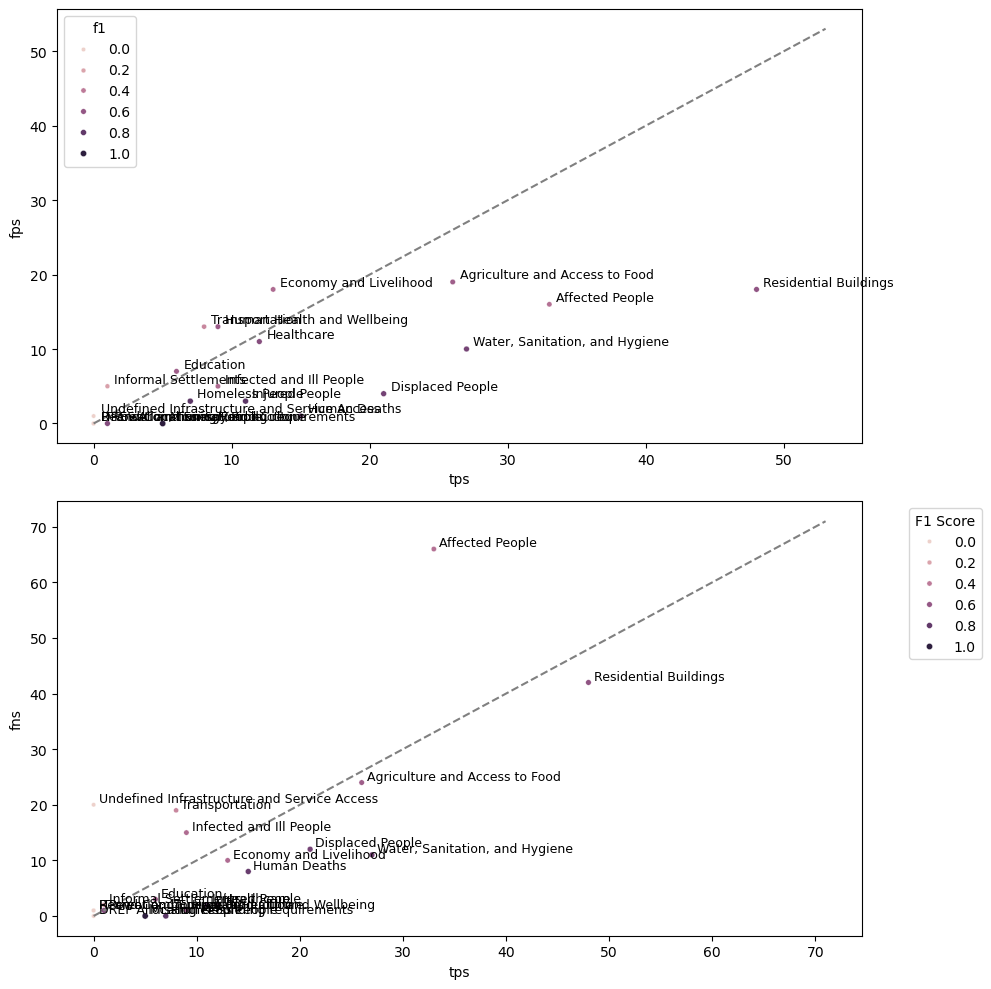

In [22]:
import seaborn as sns

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(10,10))
xkey = "tps"
ykeys = ["fps", "fns"]
for i, ykey in enumerate(ykeys):
    ax = axes[i]

    sns.scatterplot(
        ax=ax,
        data=f1_bs_by_subtype,
        x=xkey,
        y=ykey,
        hue="f1",
        size="f1",
        sizes=(10, 20),
        legend=True,
    )
    # add impact subtype text
    for i, row in f1_bs_by_subtype.iterrows():
        ax.text(row[xkey]+0.5, row[ykey]+0.5, row["impactSubtype"], fontsize=9)

    # add 1-1 line
    max_val = max(f1_bs_by_subtype[xkey].max(), f1_bs_by_subtype[ykey].max()) + 5
    ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
    #ax.set_xlabel("Number of extracted impacts")
    #ax.set_ylabel("Number of labelled impacts")
    #ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
f1_bs_by_subtype

,impactSubtype,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err
8,Residential Buildings,48,66,90,18,42,0.615385,0.727273,0.533333,0.094837,0.083411,0.109626,0.103713,0.100038,0.098869
0,Affected People,33,49,99,16,66,0.445946,0.673469,0.333333,0.100622,0.098358,0.130624,0.130878,0.088055,0.093753
16,"Water, Sanitation, and Hygiene",27,37,38,10,11,0.720000,0.729730,0.710526,0.131765,0.109268,0.149127,0.135135,0.148064,0.143132
20,Agriculture and Access to Food,26,45,50,19,24,0.547368,0.577778,0.520000,0.133575,0.112826,0.145960,0.143185,0.140000,0.140000
2,Displaced People,21,25,33,4,12,0.724138,0.840000,0.636364,0.147215,0.119612,0.150345,0.121538,0.165775,0.163636
5,Human Deaths,15,16,23,1,8,0.769231,0.937500,0.652174,0.180995,0.139860,0.137763,0.062500,0.197628,0.204969
11,Economy and Livelihood,13,31,23,18,10,0.481481,0.419355,0.565217,0.189815,0.151852,0.169355,0.180645,0.205217,0.199488
17,Healthcare,12,23,14,11,2,0.648649,0.521739,0.857143,0.211149,0.160875,0.203557,0.198261,0.210084,0.142857
1,Injured People,11,14,13,3,2,0.814815,0.785714,0.846154,0.206119,0.118519,0.247253,0.214286,0.209790,0.153846
6,Infected and Ill People,9,14,24,5,15,0.473684,0.642857,0.375000,0.231260,0.177479,0.267857,0.246032,0.184524,0.196566


In [24]:
f1_bs_by_appeal

,appealCode,tps,n_ext,n_lab,fps,fns,f1,precision,recall,f1_low_err,f1_high_err,precision_low_err,precision_high_err,recall_low_err,recall_high_err,reportSize,appealType
0,MDRUG050,49,67,97,18,48,0.597561,0.731343,0.505155,0.091067,0.080600,0.106389,0.104722,0.101119,0.099012,19565,DREF Operation Update
1,MDRSD034,39,50,87,11,48,0.569343,0.780000,0.448276,0.100593,0.088419,0.120426,0.111304,0.102608,0.105944,30227,DREF Operation Update
2,MDRNG041,20,21,29,1,9,0.800000,0.952381,0.689655,0.133333,0.109091,0.112548,0.047619,0.172414,0.167488,10909,DREF Operation
3,MDRRW022,19,57,27,38,8,0.452381,0.333333,0.703704,0.140693,0.119048,0.115152,0.122807,0.179894,0.165862,12484,DREF Operation Final Report
4,MDRPK026,15,22,30,7,15,0.576923,0.681818,0.500000,0.185619,0.147215,0.203557,0.187747,0.178571,0.178571,12507,DREF Operation Final Report
5,MDRKE058,15,32,33,17,18,0.461538,0.468750,0.454545,0.156454,0.149573,0.168818,0.174107,0.168831,0.175084,7860,Operations Update
6,MDRCN006,14,15,15,1,1,0.933333,0.933333,0.933333,0.118519,0.066667,0.147619,0.066667,0.147619,0.066667,3609,DREF Operation Final Report
7,MDRDZ011,13,17,22,4,9,0.666667,0.764706,0.590909,0.196078,0.151515,0.226244,0.179739,0.209957,0.198565,7303,DREF Operation
8,MDRBJ019,9,14,23,5,14,0.486486,0.642857,0.391304,0.236486,0.180180,0.274436,0.232327,0.191304,0.208696,12554,DREF Operation
9,MDRCM039,8,13,17,5,9,0.533333,0.615385,0.470588,0.225641,0.172549,0.282051,0.251282,0.235294,0.235294,14542,DREF Operation


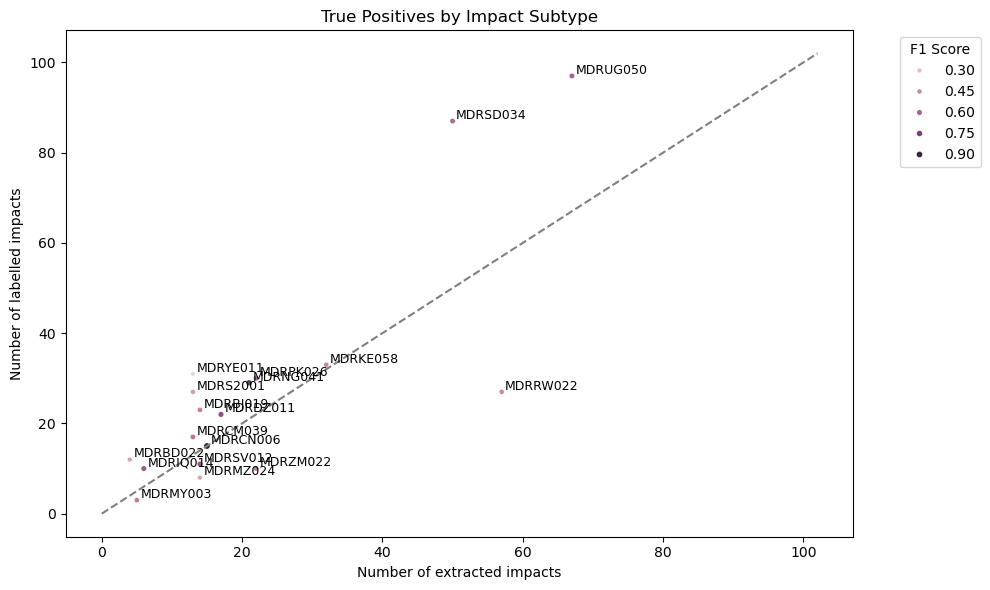

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x="n_ext",
    y="n_lab",
    hue="f1",
    size="f1",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row["n_ext"] + 0.5, row["n_lab"] + 0.5, row["appealCode"], fontsize=9)

# add 1-1 line
max_val = max(f1_bs_by_appeal["n_ext"].max(), f1_bs_by_appeal["n_lab"].max()) + 5
ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Number of extracted impacts")
ax.set_ylabel("Number of labelled impacts")
ax.set_title("True Positives by Impact Subtype")
plt.legend(title="F1 Score", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

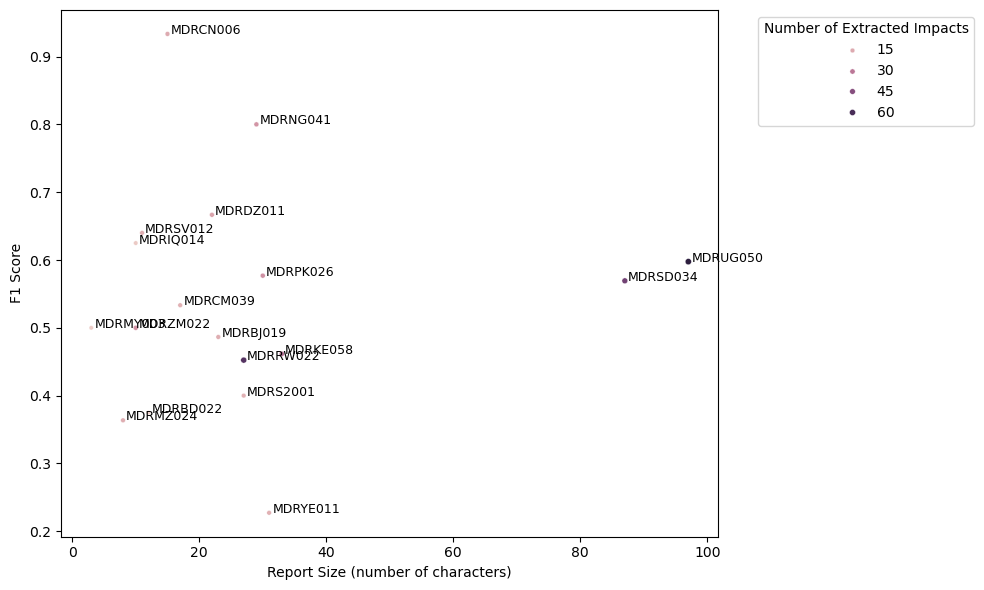

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey="n_lab"
ykey="f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

# add impact subtype text
for i, row in f1_bs_by_appeal.iterrows():
    ax.text(row[xkey] + 0.5, row[ykey], row["appealCode"], fontsize=9)

# add 1-1 line
#max_val = max(f1_bs_by_appeal[xkey].max(), f1_bs_by_appeal[ykey].max()) + 5
#ax.plot([0, max_val], [0, max_val], color="gray", linestyle="--")
ax.set_xlabel("Report Size (number of characters)")
ax.set_ylabel("F1 Score")
#ax.set_title("")
plt.legend(title="Number of Extracted Impacts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

<Axes: xlabel='tps', ylabel='f1'>

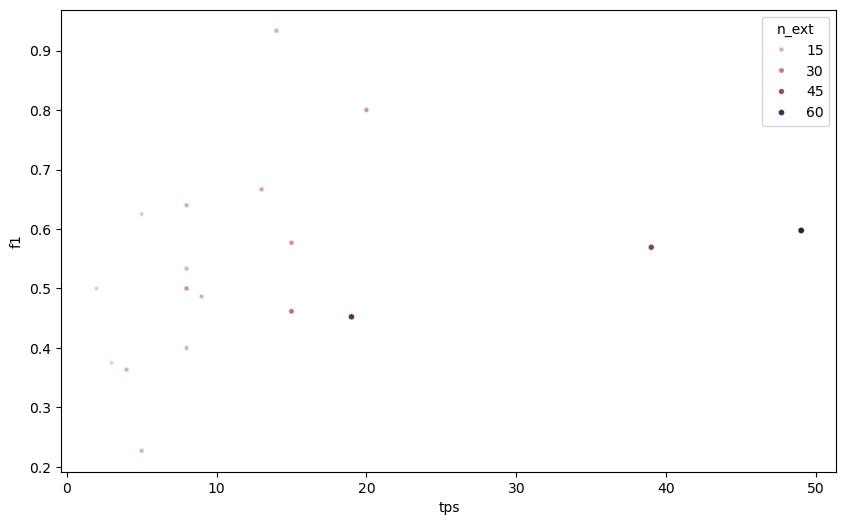

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
xkey = "tps"
ykey = "f1"
sns.scatterplot(
    ax=ax,
    data=f1_bs_by_appeal,
    x=xkey,
    y=ykey,
    hue="n_ext",
    size="n_ext",
    sizes=(10, 20),
    legend=True,
)

In [29]:
labelled_df_filter.groupby("appealCode").quanti.value_counts().unstack().mean()

quanti
quali     10.235294
quanti    17.666667
dtype: float64

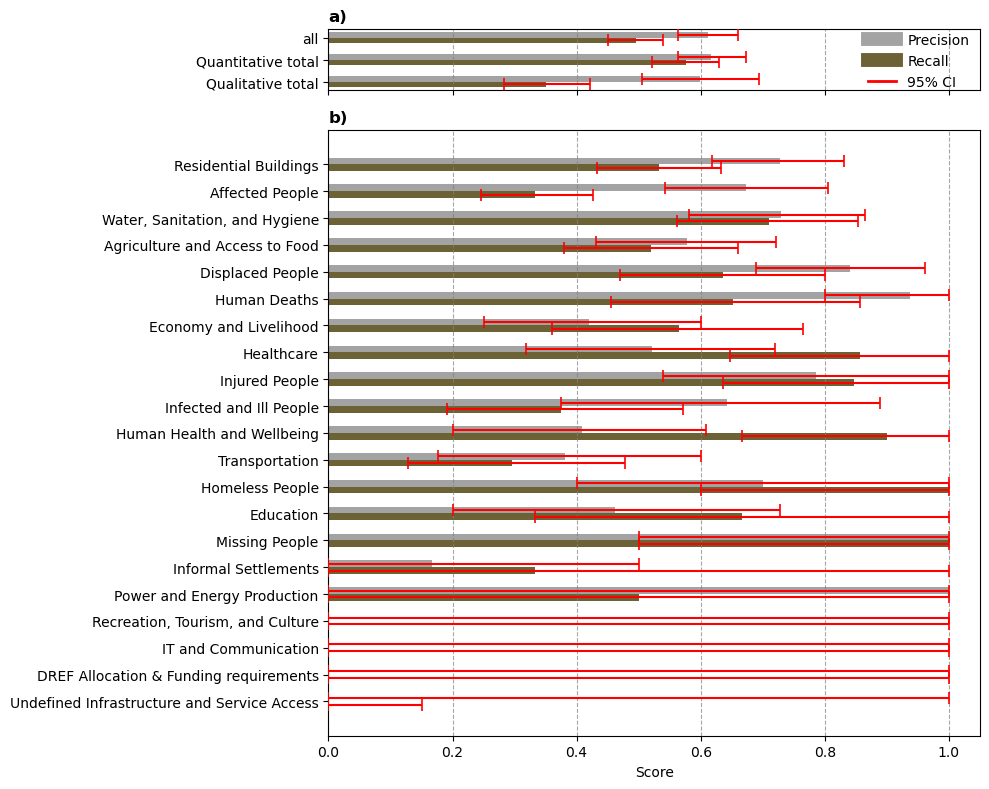

In [31]:
import textwrap
from click import group
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

metrics = ["precision", "recall"]#"f1"
colors = ["#a3a3a3", "#6c6236", "#5e0eff"]  # distinct colors for each metric
group_key = "impactSubtype"


fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharey=False, sharex=True, height_ratios=[1, 10])

# --- Function to plot grouped bars with error bars ---
def plot_metrics_with_errorbars(ax, df, x_col, metrics, colors):
    n_metrics = len(metrics)
    y_positions = np.arange(len(df))
    height = 0.25  # controls bar thickness
    spacing = 0.3  # space between metric groups

    for i, metric in enumerate(metrics):
        # compute shifted y positions for each metric
        offset = (i - (n_metrics - 1)/2) * height
        y_shifted = y_positions + offset

        val = df[f"{metric}"]
        lower = df[f"{metric}_low_err"]
        upper = df[f"{metric}_high_err"]

        ax.barh(
            y_shifted,
            val,
            height=height,
            color=colors[i],
            label=metric.capitalize()
        )

        # Add horizontal error bars
        xerr = [lower, upper]
        ax.errorbar(
            val, y_shifted, xerr=xerr,
            fmt='none', ecolor='red',
            elinewidth=1.5, capsize=4, capthick=1.2, zorder=5
        )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(df[x_col])
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)  # adjust if scores in [0,1]

# --- Plot bottom panel (all-level metrics) ---
plot_metrics_with_errorbars(ax[0], f1_bs_all, "quanti", metrics, colors)

# --- Plot top panel (by-key metrics) ---
plot_metrics_with_errorbars(ax[1], f1_bs_by_subtype, group_key, metrics, colors)

# --- Labels ---
ax[1].set_xlabel("Score")
ax[0].set_ylabel("")
ax[1].set_ylabel("")

# --- Create combined legend handles ---
err_proxy = Line2D([0], [0], color='red', lw=2, marker='_', markersize=10, label='95% CI')
bars_proxy = [Line2D([0], [0], color=c, lw=10, label=m.capitalize()) for m, c in zip(metrics, colors)]

# --- Add legend ---
#ax[1].get_legend().remove()
ax[0].legend(handles=bars_proxy + [err_proxy], loc=(0.82, -0.08), frameon=False)#title="Metrics"

ax[0].set_title("a)", fontweight="bold", loc="left")
ax[1].set_title("b)", fontweight="bold", loc="left")

## add grids
ax[0].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)
ax[1].xaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.7)

plt.tight_layout()
plt.show()

fig.savefig(DATA_FIGURE / f"{'_'.join(metrics)}_vth-{value_error_th}_sth-{sim_th}_flt_{filename_match.replace(key, MODEL_NAMES_MAP[key])}.png", bbox_inches="tight", dpi=300)

In [ ]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= sim_th)]
un_matched_quali = un_matched[(matched_df_filter1["quanti"] == "quali")]
un_matched_quanti = un_matched[(matched_df_filter1["quanti"] == "quanti")]


/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/Users/lseverino/miniforge3/envs/ifrc_llm_311/lib/python3.11/site-packages/geopandas/geodataframe.py:1896: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [ ]:
un_matched_quali.impactSubtype.value_counts()

impactSubtype
Economy and Livelihood            19
Healthcare                         7
Education                          6
Water, Sanitation, and Hygiene     5
Displaced People                   2
Agriculture and Access to Food     1
Name: count, dtype: int64

In [ ]:
un_matched_quanti.impactSubtype.value_counts()

impactSubtype
Human Health and Wellbeing                     13
Residential Buildings                           5
Economy and Livelihood                          5
Informal Settlements                            5
Agriculture and Access to Food                  4
Water, Sanitation, and Hygiene                  4
Transportation                                  2
Undefined Infrastructure and Service Access     1
Healthcare                                      1
Education                                       1
Name: count, dtype: int64

In [ ]:
un_matched.impactSubtype.value_counts()

impactSubtype
Economy and Livelihood            19
Healthcare                         7
Education                          6
Water, Sanitation, and Hygiene     5
Displaced People                   2
Agriculture and Access to Food     1
Name: count, dtype: int64

In [ ]:
un_matched.appealCode.value_counts()

appealCode
MDRRW022    19
MDRKE058    11
MDRBJ019    10
MDRZM022    10
MDRYE011     6
MDRCM039     5
MDRMZ024     4
MDRPK026     4
MDRSD034     4
MDRNG041     3
MDRUG050     3
MDRSV012     2
Name: count, dtype: int64

In [ ]:
labelled_df_filter[labelled_df_filter["appealCode"] == "MDRZM022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged,geometry,appealType
179,2024-04-02,Affected People,5000000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
180,2024-04-02,Agriculture and Access to Food,10000.0,km**2 of crop production and forestry,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
181,2024-04-02,Agriculture and Access to Food,NaN,crop production and forestry,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
182,2024-04-02,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
183,2024-04-02,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
184,2024-04-02,Agriculture and Access to Food,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
185,2024-04-02,Economy and Livelihood,NaN,null,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
186,2024-04-02,Agriculture and Access to Food,2040000.0,people,approx,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['North-Western province', 'Southern province'...",...,"['North-Western', 'Northern', 'Southern', 'Eas...",['ZMB'],[168.0],"[1717.0, 1718.0, 1719.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",DREF Operation
187,2024-04-02,Affected People,546139.0,people,exact,NaN,NaN,['Page 1 / 21 DREF Operation Zambia Drought 20...,['Zambia'],"['Kalabo district', 'Senanga district', 'Sikon...",...,"['Kalabo', 'Senanga', 'Sikongo', 'Shangombo', ...",['ZMB'],[168.0],"[1720.0, 1717.0]","[106631.0, 106642.0, 106645.0, 106644.0, 10664...",NaN,False,False,"MULTIPOLYGON (((22.04535 -14.02934, 22.0482 -1...",DREF Operation
188,2024-04-02

In [ ]:
extracted_df_filter[extracted_df_filter["appealCode"] == "MDRZM022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged,geometry,reportSize,appealType
395,Affected People,5000000.0,NaN,NaN,exact,people,['One (1) million households (five (5) million...,0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
396,Agriculture and Access to Food,10000.0,NaN,NaN,exact,km**2 of crop production and forestry,['One (1) million households (five (5) million...,0,"['Southern', 'Central', 'Eastern', 'North-west...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1718.0, 1719.0, 1713.0, 1720.0, 1711.0, 1715....","[nan, 106584.0, 106631.0, 106642.0, 106645.0, ...",NaN,False,True,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
397,Agriculture and Access to Food,2040000.0,NaN,NaN,exact,people,['The situation has come at a time when 2.04 m...,0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
398,"Water, Sanitation, and Hygiene",NaN,NaN,NaN,None,null,['Water points are drying up making it difficu...,0,"['Southern Province', 'North-Western', 'Wester...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1717.0, 1713.0, 1720.0, 1711.0, 1714.0, nan, ...","[nan, 106631.0, 106642.0, 106645.0, 106644.0, ...",NaN,False,True,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",14555,DREF Operation
399,Human Health and Wellbeing,NaN,NaN,NaN,None,null,['Some expected impacts are compromised food a...,0,"['Southern', 'Central', 'Eastern', 'North-west...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1718.0, 1719.0, 1713.0, 1720.0, 1711.0, 1715....","[nan, 106584.0, 106631.0, 106642.0, 106645.0, ...",NaN,False,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
402,Economy and Livelihood,NaN,NaN,NaN,None,null,['The price for food items and other basic com...,0,"['Southern Province', 'North-Western', 'Wester...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1717.0, 1713.0, 1720.0, 1711.0, 1714.0, nan, ...","[nan, 106631.0, 106642.0, 106645.0, 106644.0, ...",NaN,False,False,"MULTIPOLYGON (((24.08784 -10.90128, 24.09459 -...",14555,DREF Operation
403,Agriculture and Access to Food,NaN,NaN,NaN,None,null,['Pasture is drying up making is difficult for...,0,"['Southern', 'Central', 'Eastern', 'North-west...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1718.0, 1719.0, 1713.0, 1720.0, 1711.0, 1715....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
404,"Water, Sanitation, and Hygiene",NaN,NaN,NaN,None,null,['The surface and ground water have been affec...,0,"['Southern', 'North-Western', 'Western', 'Cent...",['The whole Southern half of Zambia is experie...,...,['ZMB'],[168.0],"[1718.0, 1719.0, 1717.0, 1713.0, 1720.0, 1711....","[nan, 106584.0]",NaN,False,True,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
405,Human Health and Wellbeing,46.0,NaN,NaN,exact,%,['Analysis by age groups shows that stunting i...,0,['Northern'],['Analysis by age groups shows that stunting i...,...,['ZMB'],[168.0],"[1718.0, 1719.0]",[nan],NaN,False,False,"MULTIPOLYGON (((30.79415 -8.2742, 30.79508 -8....",14555,DREF Operation
406,Economy and Livelihood,76.6,NaN,NaN,exact,%,['Reliance on rainfed agriculture drives the h...,0,['rural Zambia'],['R

In [ ]:
un_matched[un_matched["appealCode"] == "MDRZM022"]["impactValue_sim"].max()

np.float64(0.0)

In [ ]:
print_match(un_matched[un_matched["appealCode"]=="MDRRW022"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
234,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,households,roads,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,['Those affected were gathered together in IDP...,"['From 1 to 6 May, Rwanda experienced continuo..."
235,MDRRW022,Economy and Livelihood,Healthcare,NaN,NaN,households,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,['Those affected were gathered together in IDP...,"['From 1 to 6 May, Rwanda experienced continuo..."
236,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,households,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,['Those affected were gathered together in IDP...,"['From 1 to 6 May, Rwanda experienced continuo..."
241,MDRRW022,Economy and Livelihood,Healthcare,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.473414,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
242,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.473414,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
246,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,businesses,roads,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
247,MDRRW022,Economy and Livelihood,Healthcare,NaN,NaN,businesses,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
248,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,businesses,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
251,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,households capital,roads,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,"['As well, businesses, market, trade and agric...","['From 1 to 6 May, Rwanda experienced continuo..."
252,MDRRW022,Economy and Livelihood,Healthcare,NaN,NaN,households capital,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.436377,"['As well, businesses, market, trade and agric...","['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
un_matched[un_matched["impactSubtype"] == "Economy and Livelihood"][["location","location_matched","locationPolygon", "locationPolygon_matched", "locationOsm", "locationOsm_matched"]]

,location,location_matched,locationPolygon,locationPolygon_matched,locationOsm,locationOsm_matched
42,"['Far North region', 'Logone et Chari division...","['Logone et Chari division', 'Mayo Danay divis...","['Extrême-Nord', 'Cameroon', 'Logone-Et-Chari'...",['Cameroon'],"['Far-North', 'Cameroon', 'Blangoua', 'Makary'...",['Cameroon']
141,"['Tete', 'Gaza', 'Manica', 'Inhambane', 'south...",[],"['Tete', 'Gaza', 'Manica', 'Inhambane', 'Mozam...",['Mozambique'],"['Tete Province', 'Gaza Province', 'Manica Pro...",['Mozambique']
188,['Punjab'],[],['Punjab'],['Pakistan'],['Punjab'],['Pakistan']
189,['Punjab'],[],['Punjab'],['Pakistan'],['Punjab'],['Pakistan']
234,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...","['Iburengerazuba', 'Muhanga', 'Nyabihu', 'Karo...","['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Ngororero', 'Rutsiro', 'Muhanga', 'Mukamira'..."
235,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...","['Iburengerazuba', 'Muhanga', 'Nyabihu', 'Karo...","['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Ngororero', 'Rutsiro', 'Muhanga', 'Mukamira'..."
236,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...","['Iburengerazuba', 'Muhanga', 'Nyabihu', 'Karo...","['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Ngororero', 'Rutsiro', 'Muhanga', 'Mukamira'..."
241,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...","['Iburengerazuba', 'Muhanga', 'Nyabihu', 'Karo...","['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Ngororero', 'Rutsiro', 'Muhanga', 'Mukamira'..."
242,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...","['Iburengerazuba', 'Muhanga', 'Nyabihu', 'Karo...","['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Ngororero', 'Rutsiro', 'Muhanga', 'Mukamira'..."
246,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...","['Iburengerazuba', 'Amajyaruguru', 'Musanze', ...","['Iburengerazuba', 'Muhanga', 'Nyabihu', 'Karo...","['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Ngororero', 'Rutsiro', 'Muhanga', 'Mukamira'..."


In [ ]:
print_match(un_matched[un_matched["impactSubtype"]=="Economy and Livelihood"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
42,MDRCM039,Economy and Livelihood,Affected People,NaN,NaN,null,null,"['Far North region', 'Logone et Chari division...","['Logone et Chari division', 'Mayo Danay divis...",0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.00000,0.442146,['All these factors significantly affect the r...,['Series of floods have been recorded since Au...
141,MDRMZ024,Economy and Livelihood,Undefined Infrastructure and Service Access,NaN,NaN,null,null,"['Tete', 'Gaza', 'Manica', 'Inhambane', 'south...",[],0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.00000,0.479570,['The compounded effects of these events have ...,['1 OPERATION UPDATE Mozambique | Drought Emer...
188,MDRPK026,Economy and Livelihood,Human Health and Wellbeing,NaN,NaN,null,null,['Punjab'],[],0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.00000,0.449720,"['In Punjab, on the other hand, faced riverine...","['The situation led to major health concerns, ..."
189,MDRPK026,Economy and Livelihood,"Water, Sanitation, and Hygiene",NaN,NaN,null,null,['Punjab'],[],0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.00000,0.449720,"['In Punjab, on the other hand, faced riverine...","['The situation led to major health concerns, ..."
234,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,households,roads,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.00000,0.436377,['Those affected were gathered together in IDP...,"['From 1 to 6 May, Rwanda experienced continuo..."
235,MDRRW022,Economy and Livelihood,Healthcare,NaN,NaN,households,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.00000,0.436377,['Those affected were gathered together in IDP...,"['From 1 to 6 May, Rwanda experienced continuo..."
236,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,households,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.00000,0.436377,['Those affected were gathered together in IDP...,"['From 1 to 6 May, Rwanda experienced continuo..."
241,MDRRW022,Economy and Livelihood,Healthcare,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.00000,0.473414,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
242,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.00000,0.473414,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
246,MDRRW022,Economy and Livelihood,Transportation,NaN,NaN,businesses,roads,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.00000,0.436377,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
un_matched.appealCode.value_counts()

appealCode
MDRRW022    14
MDRBJ019    10
MDRKE058     6
MDRCM039     5
MDRMZ024     2
MDRPK026     2
MDRSD034     1
Name: count, dtype: int64

In [ ]:
labelled_df[labelled_df["appealCode"] == "MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationPolygon,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged,geometry,appealType
471,2024-09-05,Affected People,60000.0,people,exact,NaN,NaN,['DREF Final Report Rwanda - Floods and Landsl...,['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
472,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
473,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
474,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
475,2024-09-05,"Water, Sanitation, and Hygiene",NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,True,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
476,2024-09-05,Transportation,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,True,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
477,2024-09-05,"Water, Sanitation, and Hygiene",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,True,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
478,2024-09-05,Agriculture and Access to Food,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,True,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
479,2024-09-05,Agriculture and Access to Food,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,True,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report
480,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,['Rwanda'],['RWA'],[152.0],[nan],[nan],NaN,False,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",DREF Operation Final Report


In [ ]:
extracted_df[extracted_df["appealCode"] == "MDRRW022"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,location,locationAnnotation,...,iso3_code,gaul0_code,gaul1_code,gaul2_code,impactValueApprox,flag_pop_cntry,flag_impactSubtype_merged,geometry,reportSize,appealType
177,Affected People,51000.0,NaN,NaN,exact,people,"['Overall, 14 districts experienced flooding a...",0,"['North Province', 'South Province', 'West Pro...","['Overall, 14 districts experienced flooding a...",...,['RWA'],[152.0],"[nan, 1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484,DREF Operation Final Report
178,Human Deaths,137.0,NaN,NaN,exact,people,"['A total of 137 people died, and 5,472 houses...",0,"['Western Province', 'Northern Province', 'Sou...",['According to assessments carried out by the ...,...,['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report
179,Residential Buildings,5472.0,NaN,NaN,exact,homes,"['A total of 137 people died, and 5,472 houses...",0,"['Western Province', 'Northern Province', 'Sou...","['In Western Province, 6 districts with signif...",...,['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report
180,Displaced People,38000.0,NaN,NaN,exact,people,['Information reported by branches on 3rd stat...,0,"['Western Province', 'Northern Province', 'Sou...",['Information reported by branches on 3rd stat...,...,['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report
181,Transportation,8.0,NaN,NaN,exact,roads,"['In addition, in different regions of the cou...",0,[],"['In addition, in different regions of the cou...",...,['RWA'],[152.0],[nan],[nan],NaN,False,True,"MULTIPOLYGON (((30.4191 -1.13466, 30.81613 -1....",12484,DREF Operation Final Report
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,Human Health and Wellbeing,NaN,NaN,NaN,exact,living conditions,['Considering those families whose households ...,0,"['Western Province', 'Northern Province', 'Sou...","['In Western Province, 6 districts with signif...",...,['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report
268,Economy and Livelihood,NaN,NaN,NaN,exact,capital resources,"['As well, businesses, market, trade and agric...",0,"['Western Province', 'Northern Province', 'Sou...","['In Western Province, 6 districts with signif...",...,['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report
269,Economy and Livelihood,NaN,NaN,NaN,exact,trade activities,"['As well, businesses, market, trade and agric...",0,"['Western Province', 'Northern Province', 'Sou...","['In Western Province, 6 districts with signif...",...,['RWA'],[152.0],"[1557.0, 1554.0, 1555.0]","[nan, 105408.0, 105407.0, 105413.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report
270,Human Health and Wellbeing,NaN,NaN,NaN,exact,people,['The injuries sustained by individuals and th...,0,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",['Water treatment plants were flooded and non-...,...,['RWA'],[152.0],"[1557.0, 1558.0, nan, 1556.0]","[nan, 105434.0, 105423.0]",NaN,False,False,"MULTIPOLYGON (((29.49935 -1.56369, 29.49944 -1...",12484,DREF Operation Final Report


In [ ]:
cat = "Healthcare"
ext_df = extracted_df_filter[extracted_df_filter["impactSubtype"]==cat]
lab_df = labelled_df_filter[labelled_df_filter["impactSubtype"]==cat]
m_df1 = matched_df_filter1[matched_df_filter1["impactSubtype"]==cat]
m_df2 = matched_df_filter2[matched_df_filter2["impactSubtype"]==cat]
make_coverage_accuracy_df(ext_df, lab_df, m_df2, group_key="impactSubtype", group_keys=[cat]).reset_index(drop=False, names=["impactSubtype"])

,impactSubtype,nb labelled,nb extracted,coverage,true_positives,false_negatives,false_positives,precision,recall,f1,quanti
0,Healthcare,7,11,157.142857,5,2,6,0.454545,0.714286,0.555556,quanti
1,Healthcare,7,12,171.428571,6,1,6,0.500000,0.857143,0.631579,quali


In [ ]:
print_match(m_df2)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
112,MDRKE058,Healthcare,Healthcare,59.0,59.0,healthcare structures,healthcare structures,[],[],1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.000000,0.916667,"['Destroyed infrastructure, health and educati...",['October November December short rains season...
199,MDRRW022,Healthcare,Healthcare,8.0,8.0,healthcare structures,healthcare structures,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",[],1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.932751,"['8 health facilities (2 health Posts, 5 healt...","['From 1 to 6 May, Rwanda experienced continuo..."
204,MDRRW022,Healthcare,Healthcare,14.0,14.0,healthcare structures,healthcare structures,['Rutsiro'],['Rutsiro'],1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.944444,['14 health centres in Rutsiro were inaccessib...,"['From 1 to 6 May, Rwanda experienced continuo..."
310,MDRSD034,Healthcare,Healthcare,80.0,80.0,healthcare structures,healthcare structures,[],[],1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.000000,0.861111,['The conflict disrupted the operations of 80%...,['The conflict disrupted the operations of 80%...
351,MDRUG050,Healthcare,Healthcare,3.0,3.0,healthcare structures,healthcare structures,"['Kolir Sub County', 'Bukedea district']",['Kolir Sub County'],1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.000000,0.781703,['This resulted in the destruction of three he...,"['Following heavy rainfall, a rise in the wate..."
186,MDRPK026,Healthcare,Healthcare,NaN,NaN,null,null,"['Sindh', 'Balochistan', 'Khyber Pakhtunkhwa']",[],1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.710762,['The stagnant water in low-lying areas and th...,"['Additionally, the stagnant water in low-lyin..."
237,MDRRW022,Healthcare,Healthcare,NaN,NaN,healthcare structures,null,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",1.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.886321,['Health teams provided first aid in flood-aff...,"['From 1 to 6 May, Rwanda experienced continuo..."
266,MDRS2001,Healthcare,Healthcare,NaN,NaN,null,null,"['Carriacou', 'Petit Martinique']",[],1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.629630,['The destruction extended to critical infrast...,"['On July 1, the hurricane made landfall in Gr..."
267,MDRS2001,Healthcare,Healthcare,NaN,NaN,null,null,"['Carriacou', 'Petit Martinique']",['Union Island'],1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.629630,['The destruction extended to critical infrast...,"['On July 1, the hurricane made landfall in Gr..."
269,MDRS2001,Healthcare,Healthcare,NaN,NaN,null,null,['Union Island'],[],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.740741,['Saint Vincent and the Grenadines experienced...,"['On July 1, the hurricane made landfall in Gr..."


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["impactSubtype_sim"] <= 0.8)]).value_counts("impactSubtype")

impactSubtype
Economy and Livelihood                         25
Healthcare                                     17
Human Health and Wellbeing                     16
Agriculture and Access to Food                  8
Education                                       8
Informal Settlements                            6
Water, Sanitation, and Hygiene                  6
Affected People                                 3
Homeless People                                 3
Displaced People                                2
Residential Buildings                           2
Missing People                                  1
Transportation                                  1
Undefined Infrastructure and Service Access     1
Name: count, dtype: int64

In [ ]:
un_matched = matched_df_filter1[(matched_df_filter1["match_sim"] <= 0.5) & (matched_df_filter1["quanti"] == "quali")]
for groupid, group in un_matched.groupby("impactSubtype"):
    print(groupid)
    print(group.value_counts("impactSubtype_matched"))

Agriculture and Access to Food
impactSubtype_matched
Affected People    1
Name: count, dtype: int64
Displaced People
impactSubtype_matched
Affected People               1
Human Health and Wellbeing    1
Name: count, dtype: int64
Economy and Livelihood
impactSubtype_matched
Transportation                                 9
Healthcare                                     5
Human Health and Wellbeing                     2
Affected People                                1
Undefined Infrastructure and Service Access    1
Water, Sanitation, and Hygiene                 1
Name: count, dtype: int64
Education
impactSubtype_matched
Agriculture and Access to Food    2
Economy and Livelihood            2
Human Health and Wellbeing        1
Water, Sanitation, and Hygiene    1
Name: count, dtype: int64
Healthcare
impactSubtype_matched
Agriculture and Access to Food    2
Affected People                   1
Economy and Livelihood            1
Human Health and Wellbeing        1
Informal Settlements       

In [ ]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES).reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

NameError: name 'IMPACT_SUBTYPES' is not defined

In [ ]:
appeal="MDRCM039"
ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
matched_appeal_flt = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal_flt, group_key="impactSubtype", group_keys=["Targeted People"]).reset_index(drop=False, names=["impactSubtype"])

In [ ]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,garbage/coverage,quanti
0,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quanti
1,Targeted People,0,0,NaN,0,NaN,0,0,NaN,quali


In [ ]:
print_match(matched_appeal[matched_appeal["match_sim"] < 0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
61,MDRCM039,Displaced People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
62,MDRCM039,Homeless People,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Yagoua', 'Blangoua', 'Mackary', 'Zina', 'Mag...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.592593,['Tens of thousands of victims are currently l...,['The peak of the floods was recorded on Augus...
63,MDRCM039,Access to Food,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Far North region', 'Logone et Chari division...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.496823,['The lack of communication with the community...,['The peak of the floods was recorded on Augus...
64,MDRCM039,"Access to Water, Sanitation, and Hygiene",Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.518519,['Water sources (wells and water points) have ...,['The peak of the floods was recorded on Augus...


In [ ]:
print_match(matched_appeal)

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
49,MDRCM039,Affected People,Affected People,158620.000000,400.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
50,MDRCM039,Affected People,Affected People,158620.000000,200.00,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.826087,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
51,MDRCM039,Targeted People,Affected People,4800.000000,400.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
52,MDRCM039,Targeted People,Affected People,4800.000000,200.00,people,people,"['Extrême-Nord', 'Mayo Danay division', 'Logon...",['Mokolo district'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.500000,"['People Targeted: 4,800 people']","['Notably, in the Diamar division, where Ndouk..."
53,MDRCM039,DREF Allocation,Affected People,448994.353894,158620.00,EUR,null,"['Far North region', 'Extrême-Nord', 'Logone e...",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","[""Appeal MDRCM039 Country Cameroon Hazard Floo..."
54,MDRCM039,DREF Allocation,Affected People,448994.353894,400.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Ndoukoula district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,DREF Allocation,Affected People,448994.353894,200.00,EUR,people,"['Far North region', 'Extrême-Nord', 'Logone e...",['Mokolo district'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.304348,"['DREF Allocation: CHF 421,471']","['Notably, in the Diamar division, where Ndouk..."
56,MDRCM039,Residential Buildings,Residential Buildings,8690.000000,8690.00,homes,homes,"['Logone et Chari division', 'Mayo Danay divis...",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.806380,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
57,MDRCM039,Affected Livestock and Animals,Affected Livestock and Animals,10178.000000,10178.00,affected animals,affected animals,"['Logone et Chari', 'Mayo Danay']",['Far North region'],1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.819700,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...
58,MDRCM039,Agricultural Infrastructure,Crop Production and Forestry,29.980000,29.98,km**2 of crop production and forestry,km**2 of crop production and forestry,"['Logone et Chari', 'Mayo Danay']",['Far North region'],0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.558830,['The provisional report consolidated by the w...,['The provisional report consolidated by the w...


In [ ]:
print_match(matched_df_filter2[(matched_df_filter2["match_sim"]<0.6) & (matched_df_filter2["appealCode"]=="MDRKE058")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Access to Power and Energy"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched


In [ ]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,impactValue_sim,match_sim,impactValue_error,quanti,appealType,flag_remove_cat
49,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,395.55,quanti,DREF Operation,False
50,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,1.0,1.0,1.0,1.0,0.0,0.826087,792.10,quanti,DREF Operation,False


In [ ]:
print_match(matched_df_filter1[(matched_df_filter1["match_sim"]<0.6) & (matched_df_filter1["appealCode"]=="MDRBD022")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
15,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['It is also reported that embankments have be...
16,MDRBD022,Access to Healthcare,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",0.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.570748,['Six days of heavy rain and onrush of upstrea...,['of union affected 776 Emergency Plan of Acti...


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
173,MDRKE058,Informal Settlements,Infected and Ill People,10.0,8.0,informal settlements,people,"['Busia County', 'Kisumu', 'Homabay', 'Migori'...",['Garsen'],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,0.707107,0.280744,['49 camps have been set up within the last tw...,['October November December short rains season...
174,MDRKE058,Informal Settlements,Affected People,31015.0,31015.0,people,people,"['Nairobi County', 'Kware', 'Kibra', 'Viwandan...","['Nairobi County', 'Kware', 'Kibra', 'Viwandan...",0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.739130,"['In Nairobi County, 31,015 people (6,203 hous...","['In Nairobi County, 31,015 people (6,203 hous..."
504,MDRYE011,Informal Settlements,Informal Settlements,NaN,NaN,null,null,"['Al-Khamis camp', 'Al-Hasaba', 'Aser camp', '...",['Sanaa governorate'],1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.707107,0.838583,['the heavy rains affected 56 families in Al-K...,"[""Situation analysis Description of the disast..."


In [ ]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
126,MDRDZ011,Other Infrastructural Impacts,"Water, Sanitation, and Hygiene Infrastructure",NaN,NaN,null,undefined WASH structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
127,MDRDZ011,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,undefined power and energy production structures,['Béchar'],['Béchar'],0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.000000,0.481481,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
171,MDRKE058,Other Infrastructural Impacts,Healthcare Infrastructure,11.0,7.0,undefined structures,healthcare structures,[],[],0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.707107,0.282297,['economic activities of the areas have been s...,['October November December short rains season...
259,MDRNG041,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,"['Dantudu', 'Balakozo', 'Gidan Tudu', 'Tsitse']",[],0.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.000000,0.555556,"['The floods ravaged farmlands and livestock, ...","['The scale of destruction is unprecedented, w..."
288,MDRPK026,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Balochistan', 'Khyber Pakhtunkhwa', 'Sindh',...","['Jacobabad', 'Naushero Feroz', 'Ghotki', 'Suk...",1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.707107,0.941267,['The monsoon season causing significant infra...,"['Areas such as Jacobabad, Naushero Feroz, Gho..."
370,MDRRW022,Other Infrastructural Impacts,IT and Communication Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
371,MDRRW022,Other Infrastructural Impacts,Power and Energy Production Infrastructure,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
372,MDRRW022,Other Infrastructural Impacts,Access to Healthcare,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
373,MDRRW022,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."
374,MDRRW022,Other Infrastructural Impacts,Access to Education,NaN,NaN,null,null,"['Rutsiro', 'Muhanga', 'Ngororero', 'Rubavu', ...",[],0.0,...,1.0,1.0,1.0,1.0,0.0,0.0,1.000000,0.555556,"['8 national roads, 9 district roads and 26 br...","['From 1 to 6 May, Rwanda experienced continuo..."


In [ ]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     242
EUR                                       66
people                                    24
%                                          3
percent                                    2
km**2 of crop production and forestry      1
yuan                                       1
undefined structures                       1
informal settlements                       1
women                                      1
children under 5                           1
children                                   1
Name: count, dtype: int64

In [ ]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
47,people,False
48,people,False
49,people,False
50,people,False
51,km**2 of crop production and forestry,False
52,null,False
53,EUR,False
54,EUR,False
55,people,False
56,EUR,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


In [ ]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType,flag_remove_cat
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report,False
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report,False
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report,False


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

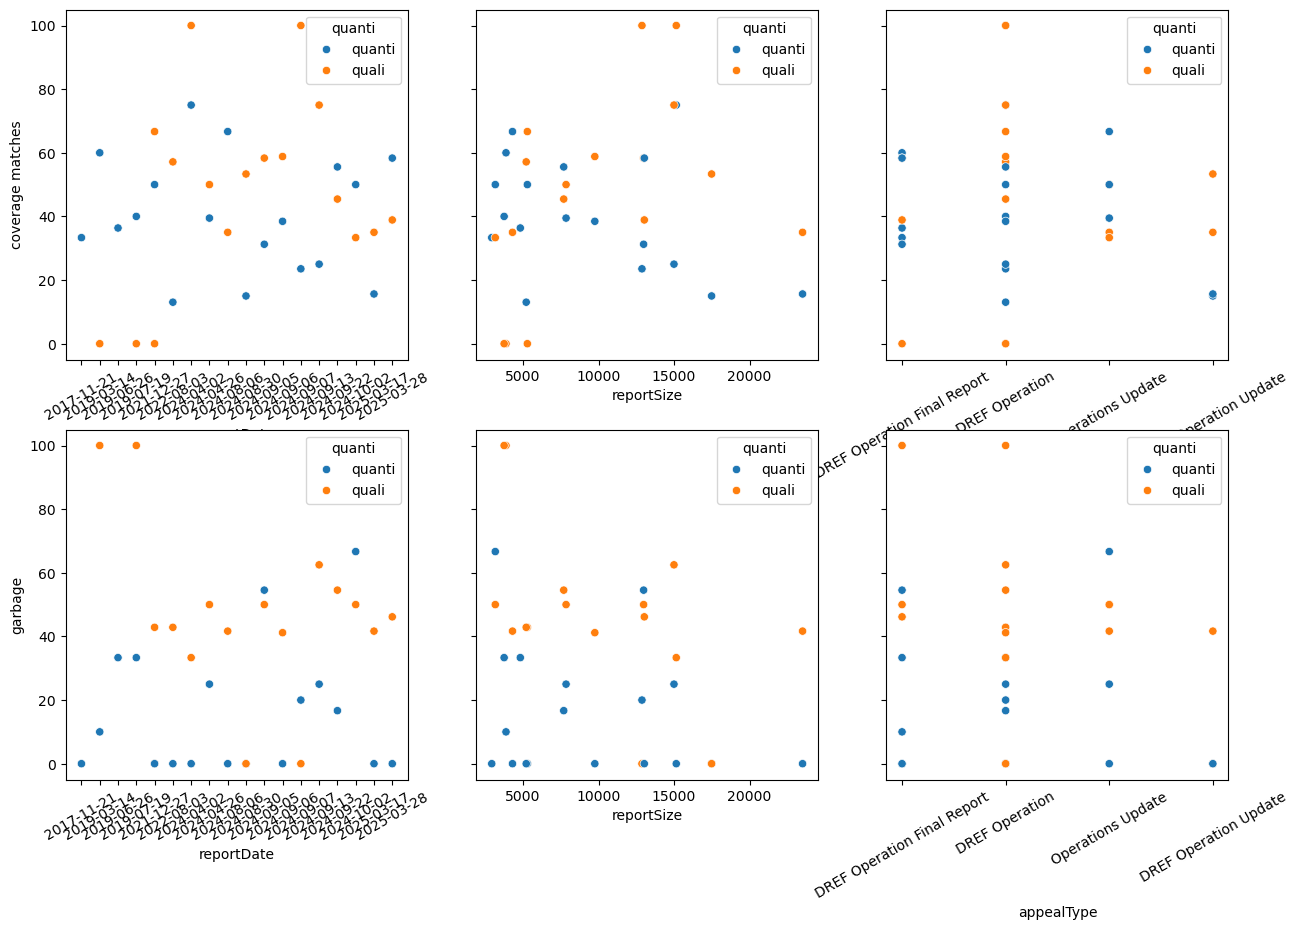

In [ ]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [ ]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

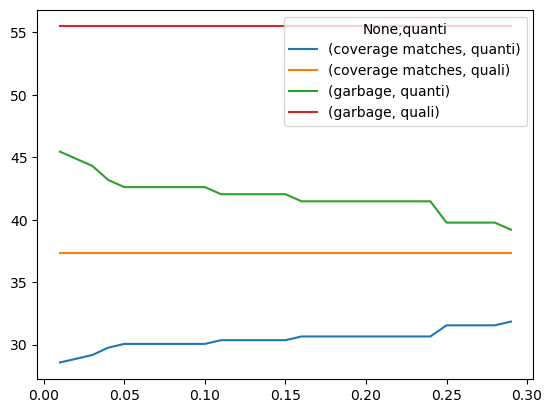

In [ ]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

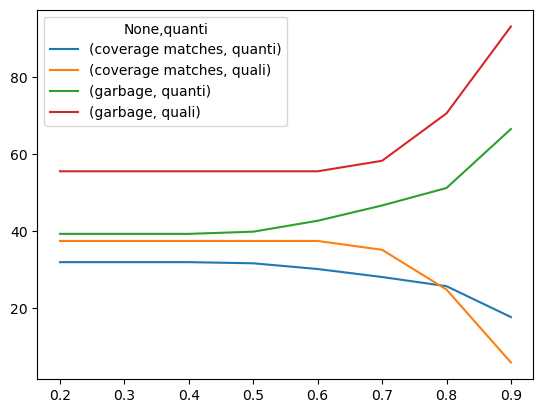

In [ ]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [ ]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


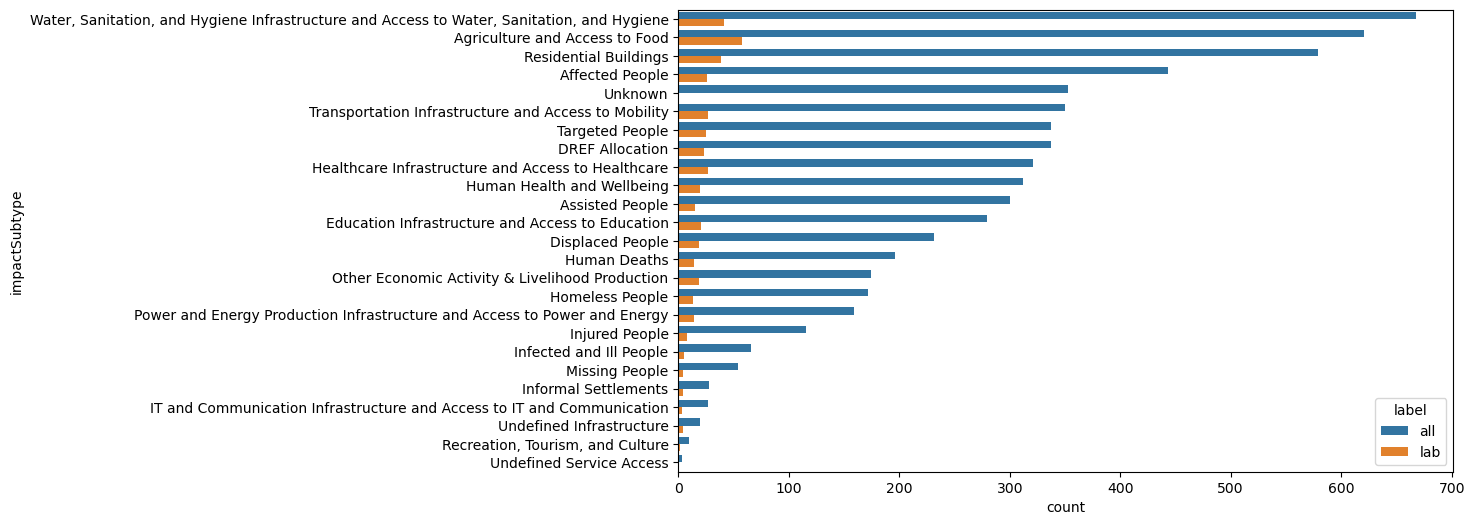

In [ ]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
